In [1]:
import sys

sys.path.insert(0, '/home/caron/Bureau/Model/HexagonalScale/ST-GNN-for-wildifre-prediction/Prediction')

from config import *
from tools import *
from features import *

path_to_dfs = Path('firemen/firepoint/2x2/test/occurence_voting/')
regions_france = gpd.read_file('regions/firepoint/firemen/regions.geojson')

/home/caron/Bureau/.conda/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nom de l'hôte : caron-Precision-7780
Adresse IP locale : 127.0.1.1
Nom de l'hôte : caron-Precision-7780
Adresse IP locale : 127.0.1.1
Nom de l'hôte : caron-Precision-7780
Adresse IP locale : 127.0.1.1


In [2]:
def susectibility_map_france_daily_geojson(df_res, regions_france, graph, dates, band,
                                           vmax_band, dept_reg):
    
    regions_france_in_graph = regions_france[regions_france['departement'] == dept_reg]
    array = regions_france_in_graph[['longitude', 'latitude']].values
    values, _ = graph._predict_node_graph_with_position(array)
    regions_france_in_graph['id'] = values
    for date_index in dates:
        date = allDates[date_index]
        logger.info(f'susectibility_map_france_daily for {date}')
        df_res_daily = df_res[df_res['date'] == date_index]

        for col in ['risk', 'nbsinister', 'prediction', 'class']:
            if col in regions_france_in_graph.columns:
                regions_france_in_graph.drop(col, inplace=True, axis=1)

        regions_france_in_graph = regions_france_in_graph.set_index('id').join(df_res_daily.set_index('id')[['prediction', 'nbsinister']], on='id').reset_index()

        regions_france_in_graph['latitude'] = regions_france_in_graph['geometry'].apply(lambda x : float(x.centroid.y))
        regions_france_in_graph['longitude'] = regions_france_in_graph['geometry'].apply(lambda x : float(x.centroid.x))
        
        fig, ax = plt.subplots(1, 3, figsize=(15,5))
        regions_france_in_graph.plot(column=band, vmin=0, vmax=vmax_band, cmap='jet', ax=ax[0])
        sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=vmax_band))
        sm.set_array([])
        fig.colorbar(sm, ax=ax[0], orientation="vertical", label=band)
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')

        regions_france_in_graph.plot(column='id', cmap='tab10', ax=ax[1])
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')

        regions_france_in_graph.plot(column='nbsinister', cmap='jet', ax=ax[2])
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        #plt.savefig(dir_output / f'susectibility_map_daily_{outname}_{band}_{date}.png')
        #plt.close('all')

In [3]:
def load_res_departement(path_to_dfs, departement, base, model, scale):
    path_to_res = path_to_dfs / departement / f'full_0_all_{scale}_0_{base}_node' / model
    fn = f'{model}_full_0_all_{scale}_0_{base}_node_z-score_Catboost_{departement}_pred.pkl'
    res = read_object(fn, path_to_res)
    return res

In [4]:
base = 'risk-size-watershed'
model = 'xgboost_search_full_all_one_nbsinister-kmeans-5-Class-Dept_classification_softmax'

In [5]:
departement = 'departement-25-doubs'

scales = ['5', '6', '7']

for scale in scales:
    dates = ['2023-08-30']
    dates = [allDates.index(d) for d in dates]
    res = load_res_departement(path_to_dfs, departement, base, model, scale)

    graph_path = Path('firemen') / 'firepoint' / '2x2' / 'train'
    graph = read_object(f'graph_{scale}_{base}_node.pkl', graph_path)

    susectibility_map_france_daily_geojson(res, regions_france, graph, dates, 'prediction', 4, departement)

2025-06-09 22:46:06,699 [INFO ]  firemen/firepoint/2x2/test/occurence_voting/departement-25-doubs/full_0_all_5_0_risk-size-watershed_node/xgboost_search_full_all_one_nbsinister-kmeans-5-Class-Dept_classification_softmax/xgboost_search_full_all_one_nbsinister-kmeans-5-Class-Dept_classification_softmax_full_0_all_5_0_risk-size-watershed_node_z-score_Catboost_departement-25-doubs_pred.pkl not found
2025-06-09 22:46:06,699 [INFO ]  firemen/firepoint/2x2/test/occurence_voting/departement-25-doubs/full_0_all_5_0_risk-size-watershed_node/xgboost_search_full_all_one_nbsinister-kmeans-5-Class-Dept_classification_softmax/xgboost_search_full_all_one_nbsinister-kmeans-5-Class-Dept_classification_softmax_full_0_all_5_0_risk-size-watershed_node_z-score_Catboost_departement-25-doubs_pred.pkl not found
2025-06-09 22:46:06,702 [INFO ]  firemen/firepoint/2x2/train/graph_5_risk-size-watershed_node.pkl not found
2025-06-09 22:46:06,702 [INFO ]  firemen/firepoint/2x2/train/graph_5_risk-size-watershed_node.

AttributeError: 'NoneType' object has no attribute '_predict_node_graph_with_position'

2025-03-10 15:04:06,497 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 15:04:06,497 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 15:04:08,704 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 15:04:08,704 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 15:04:11,381 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 15:04:11,381 [INFO ]  susectibility_map_france_daily for 2023-08-31


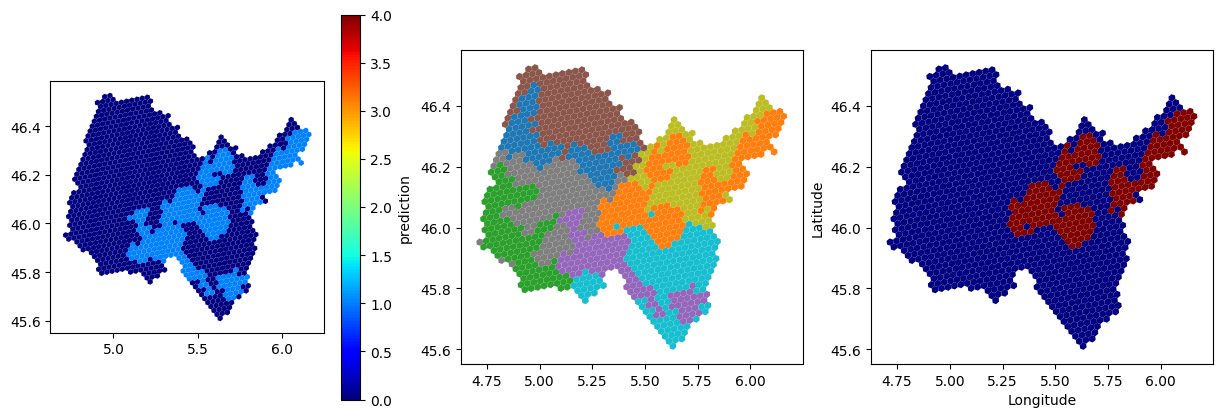

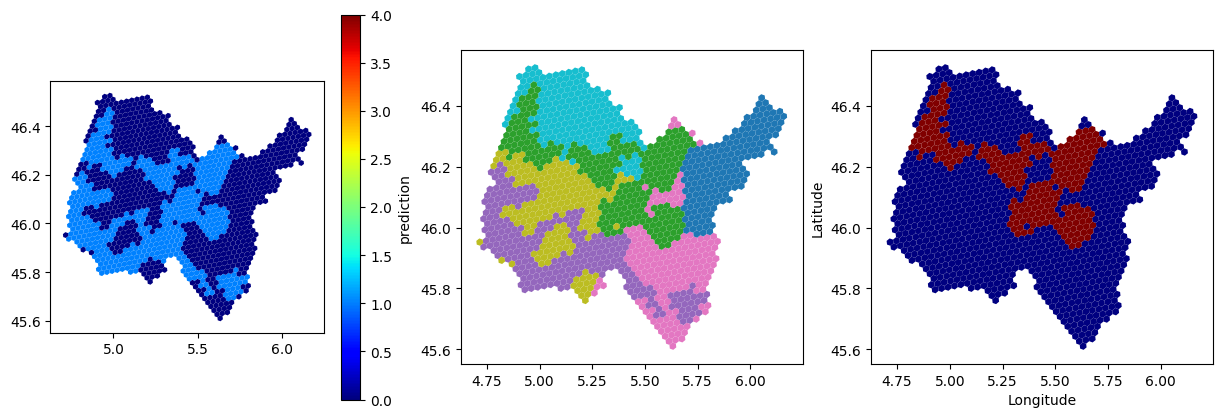

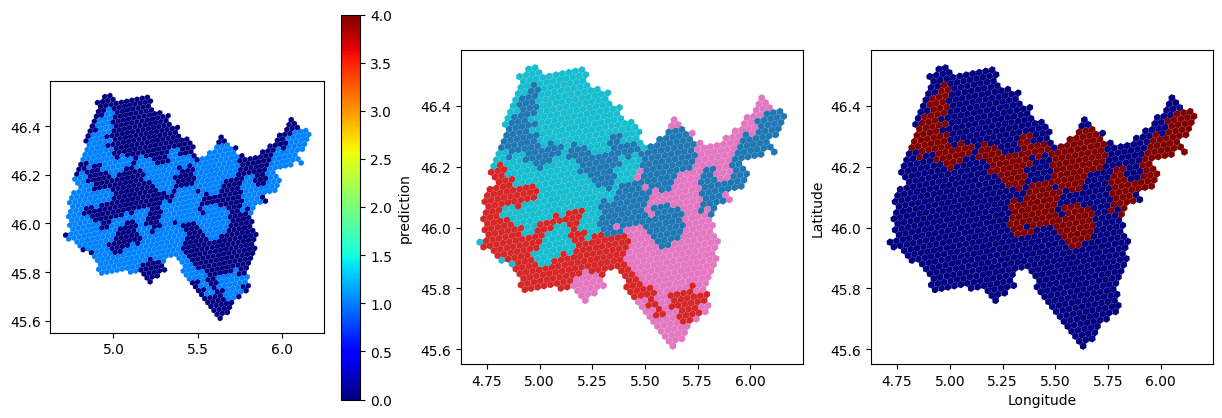

In [53]:
departement = 'departement-01-ain'

scales = ['5', '6', '7']

for scale in scales:
    dates = ['2023-08-31']
    dates = [allDates.index(d) for d in dates]
    res = load_res_departement(path_to_dfs, departement, base, model, scale)

    graph_path = Path('firemen') / 'firepoint' / '2x2' / 'train'
    graph = read_object(f'graph_{scale}_{base}_node.pkl', graph_path)

    susectibility_map_france_daily_geojson(res, regions_france, graph, dates, 'prediction', 4, departement)

2025-03-10 15:04:14,353 [INFO ]  susectibility_map_france_daily for 2023-08-27
2025-03-10 15:04:14,353 [INFO ]  susectibility_map_france_daily for 2023-08-27
2025-03-10 15:04:15,715 [INFO ]  susectibility_map_france_daily for 2023-08-27
2025-03-10 15:04:15,715 [INFO ]  susectibility_map_france_daily for 2023-08-27
2025-03-10 15:04:17,121 [INFO ]  susectibility_map_france_daily for 2023-08-27
2025-03-10 15:04:17,121 [INFO ]  susectibility_map_france_daily for 2023-08-27


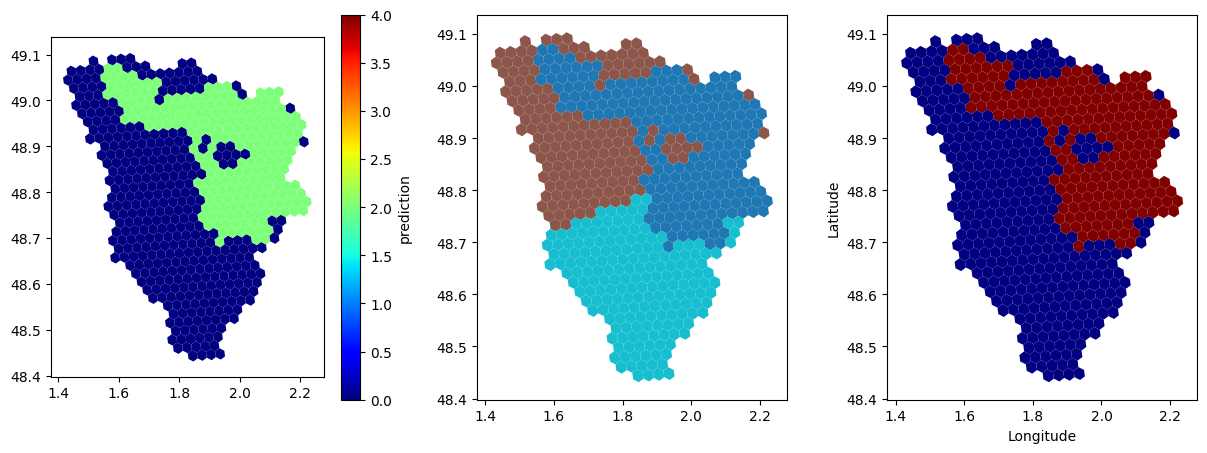

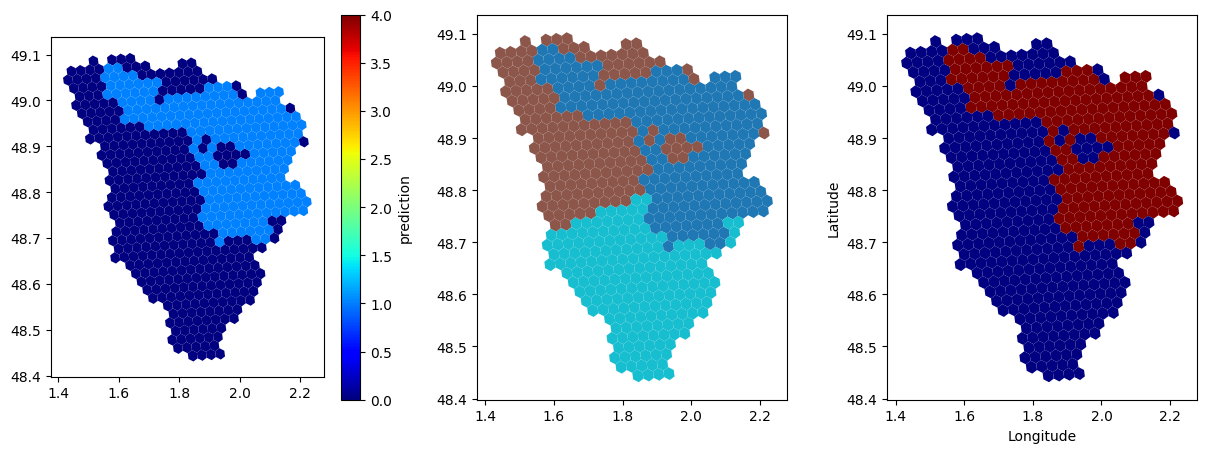

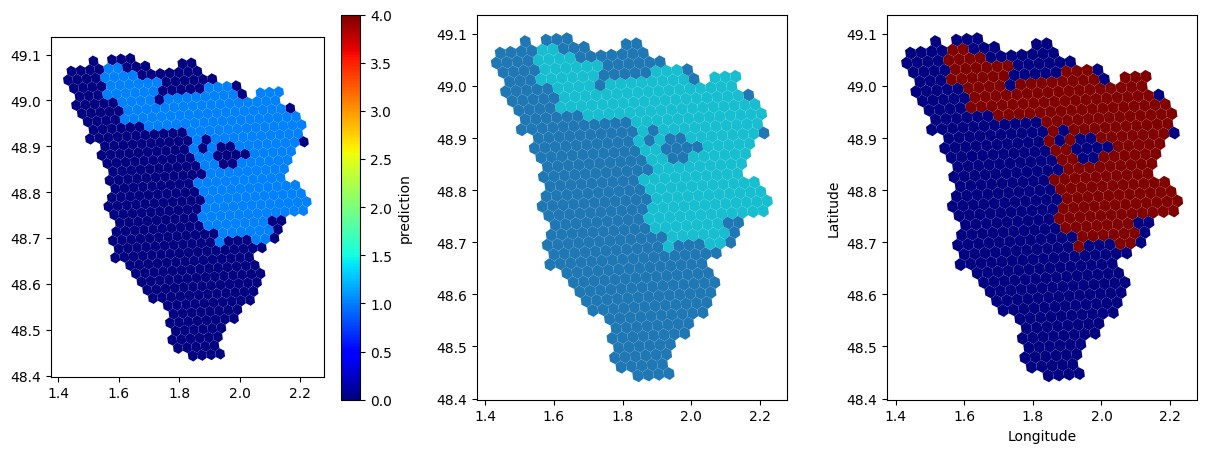

In [54]:
departement = 'departement-78-yvelines'

scales = ['5', '6', '7']

for scale in scales:
    dates = ['2023-08-27']
    dates = [allDates.index(d) for d in dates]
    res = load_res_departement(path_to_dfs, departement, base, model, scale)
    graph_path = Path('firemen') / 'firepoint' / '2x2' / 'train'
    graph = read_object(f'graph_{scale}_{base}_node.pkl', graph_path)

    susectibility_map_france_daily_geojson(res, regions_france, graph, dates, 'prediction', 4, departement)

2025-03-10 09:45:21,048 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:21,048 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:23,756 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:23,756 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:25,683 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:25,683 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:27,750 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:27,750 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:29,737 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:29,737 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:32,357 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:32,357 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:45:34,058 [INFO ]  susectibility_map_f

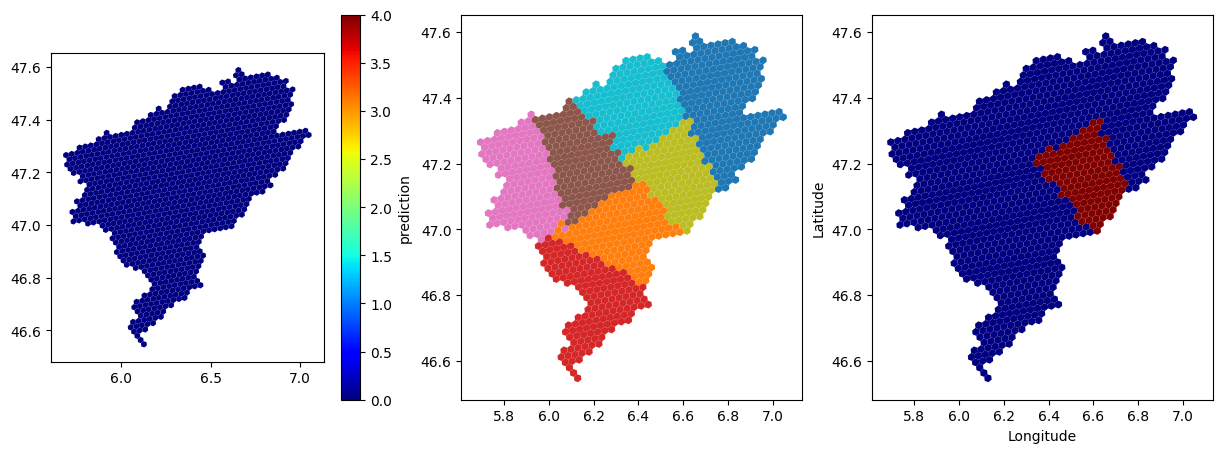

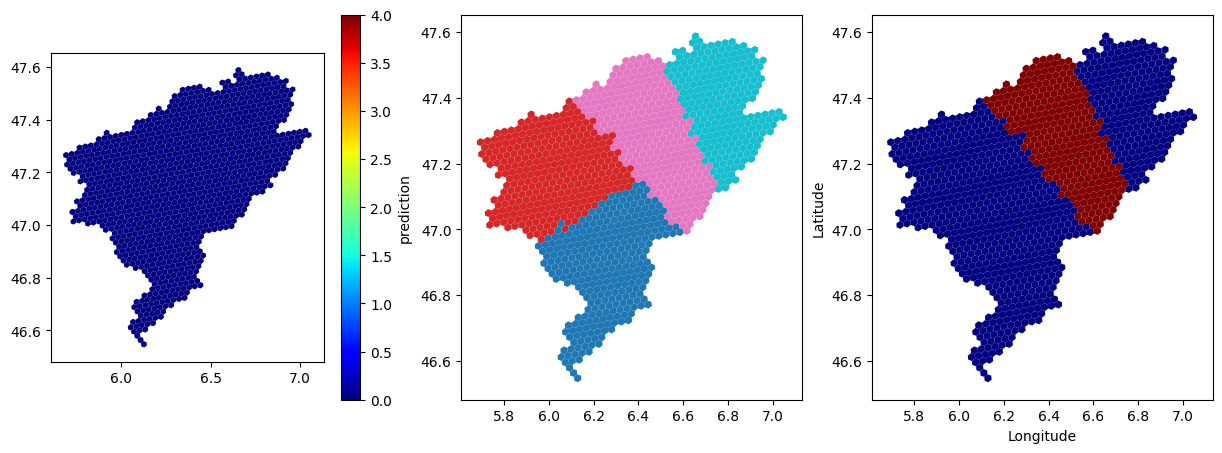

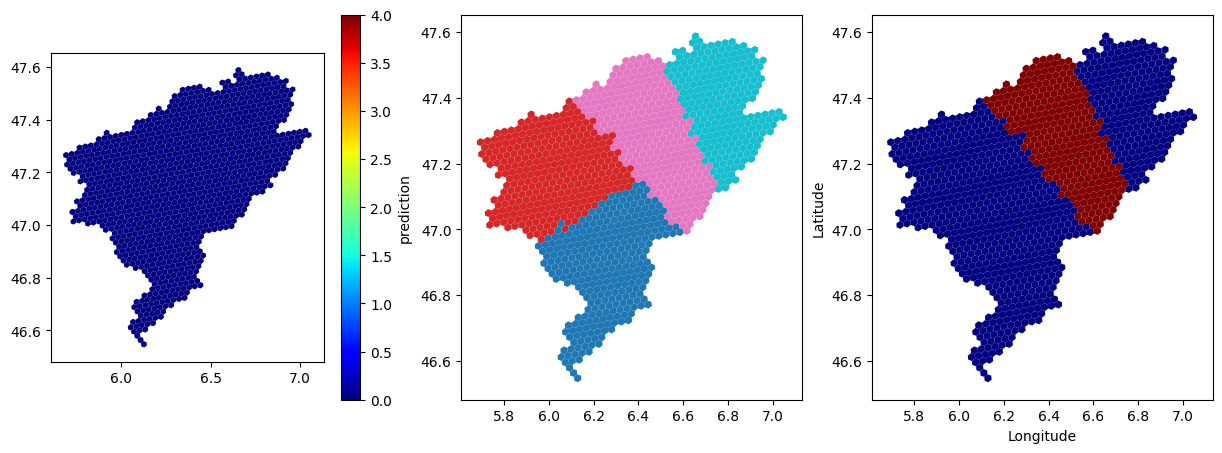

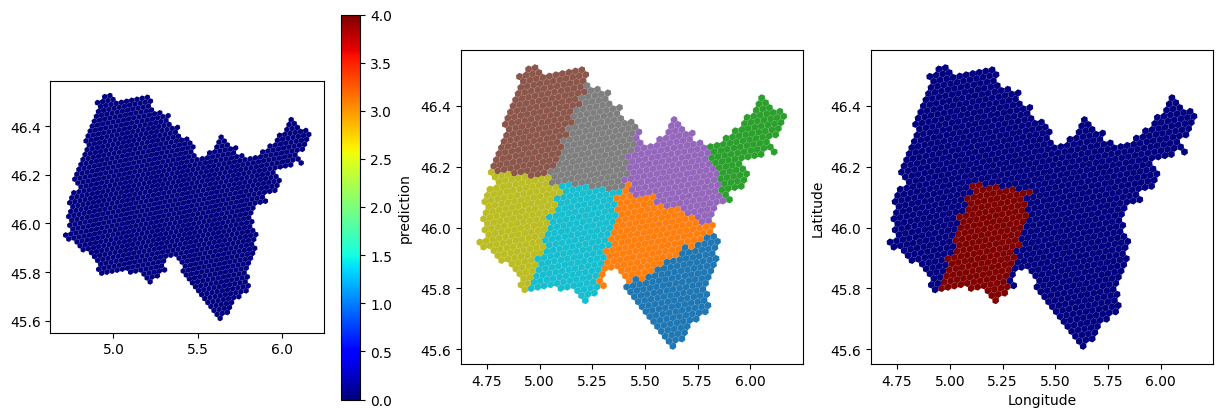

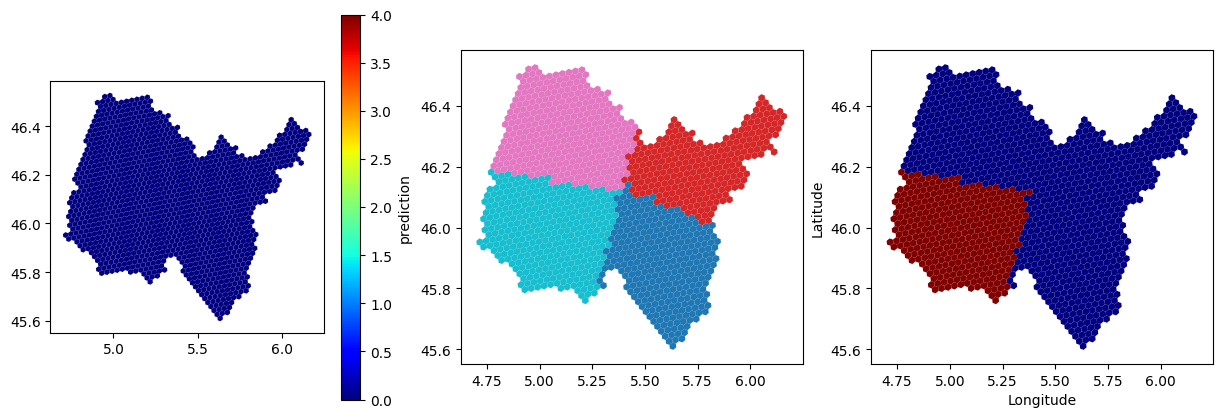

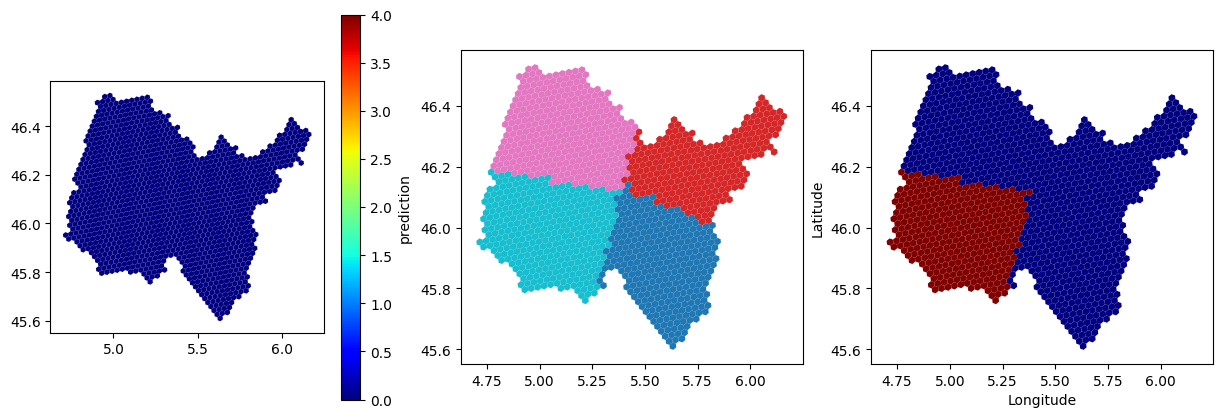

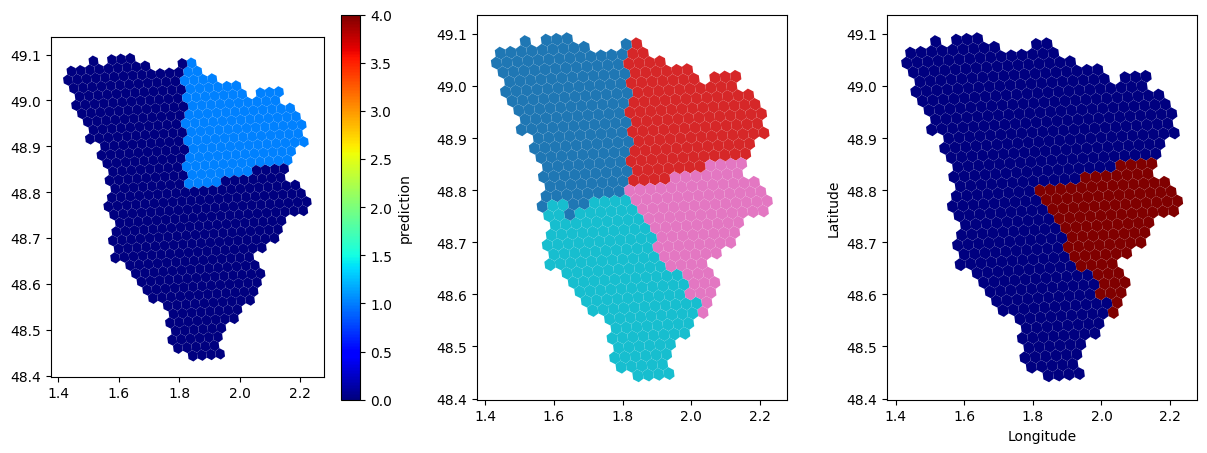

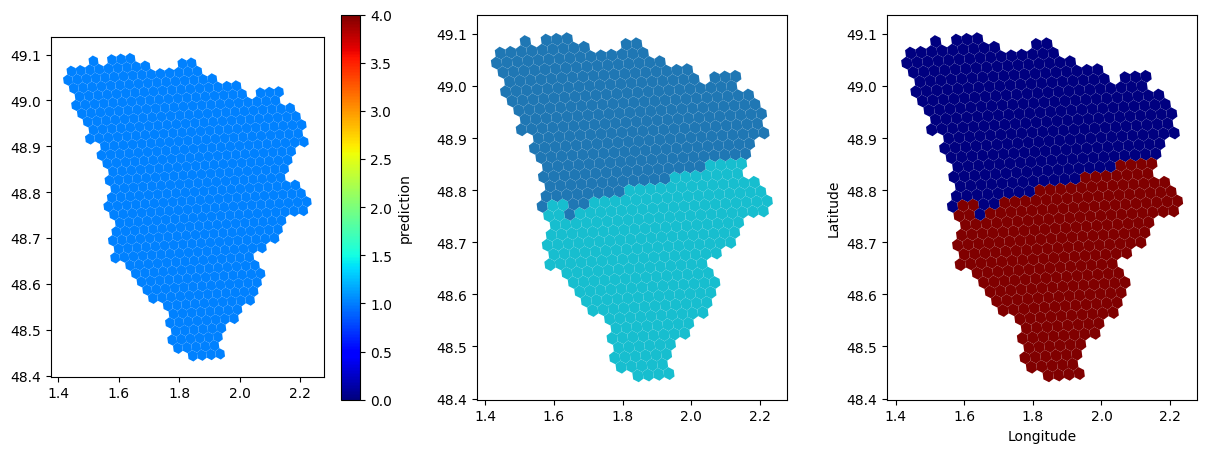

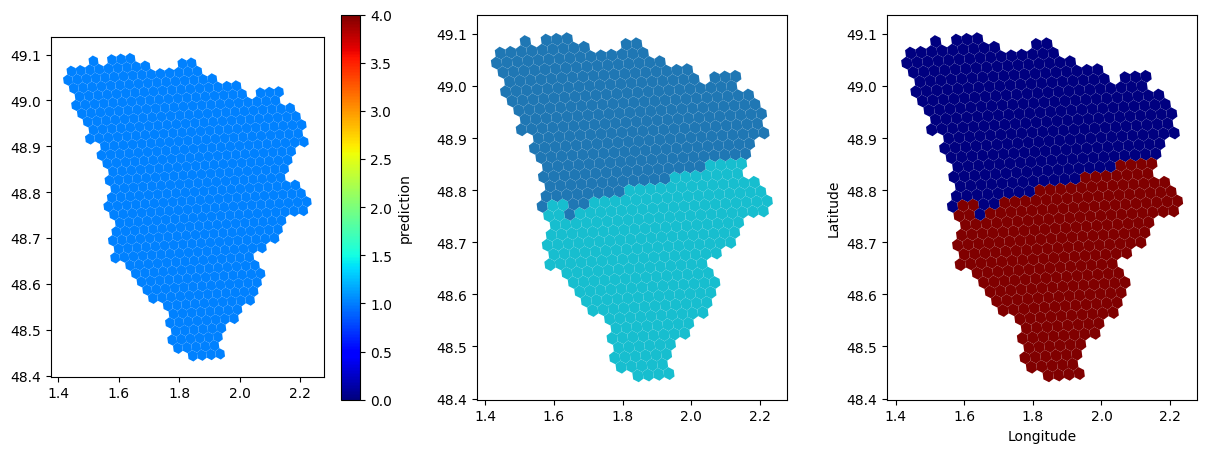

In [40]:
base = 'risk-regular'
model = 'xgboost_search_full_all_one_nbsinister-kmeans-5-Class-Dept_classification_softmax'

departement = 'departement-25-doubs'

scales = ['5', '6', '7']

for scale in scales:
    dates = ['2023-08-31']
    dates = [allDates.index(d) for d in dates]
    res = load_res_departement(path_to_dfs, departement, base, model, scale)

    graph_path = Path('firemen') / 'firepoint' / '2x2' / 'train'
    graph = read_object(f'graph_{scale}_{base}_node.pkl', graph_path)

    susectibility_map_france_daily_geojson(res, regions_france, graph, dates, 'prediction', 4, departement)


departement = 'departement-01-ain'

scales = ['5', '6', '7']

for scale in scales:
    dates = ['2023-08-31']
    dates = [allDates.index(d) for d in dates]
    res = load_res_departement(path_to_dfs, departement, base, model, scale)

    graph_path = Path('firemen') / 'firepoint' / '2x2' / 'train'
    graph = read_object(f'graph_{scale}_{base}_node.pkl', graph_path)

    susectibility_map_france_daily_geojson(res, regions_france, graph, dates, 'prediction', 4, departement)

departement = 'departement-78-yvelines'

scales = ['5', '6', '7']

for scale in scales:
    dates = ['2023-08-31']
    dates = [allDates.index(d) for d in dates]
    res = load_res_departement(path_to_dfs, departement, base, model, scale)

    graph_path = Path('firemen') / 'firepoint' / '2x2' / 'train'
    graph = read_object(f'graph_{scale}_{base}_node.pkl', graph_path)

    susectibility_map_france_daily_geojson(res, regions_france, graph, dates, 'prediction', 4, departement)

2025-03-10 09:48:17,452 [INFO ]  susectibility_map_france_daily for 2023-08-30
2025-03-10 09:48:17,452 [INFO ]  susectibility_map_france_daily for 2023-08-30
2025-03-10 09:48:18,954 [INFO ]  susectibility_map_france_daily for 2023-08-30
2025-03-10 09:48:18,954 [INFO ]  susectibility_map_france_daily for 2023-08-30
2025-03-10 09:48:21,175 [INFO ]  susectibility_map_france_daily for 2023-08-30
2025-03-10 09:48:21,175 [INFO ]  susectibility_map_france_daily for 2023-08-30
2025-03-10 09:48:22,810 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:48:22,810 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:48:24,785 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:48:24,785 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:48:26,762 [INFO ]  susectibility_map_france_daily for 2023-08-31
2025-03-10 09:48:26,762 [INFO ]  susectibility_map_france_daily for 2023-08-31


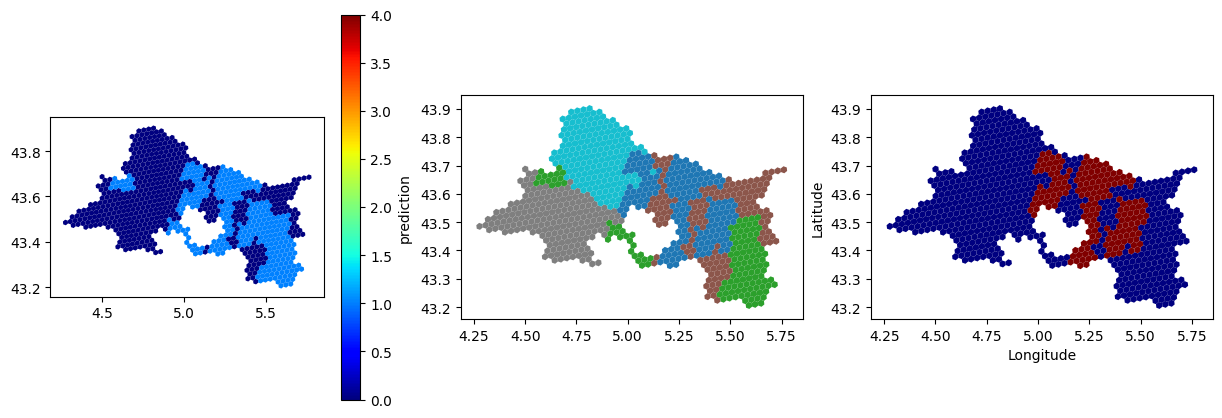

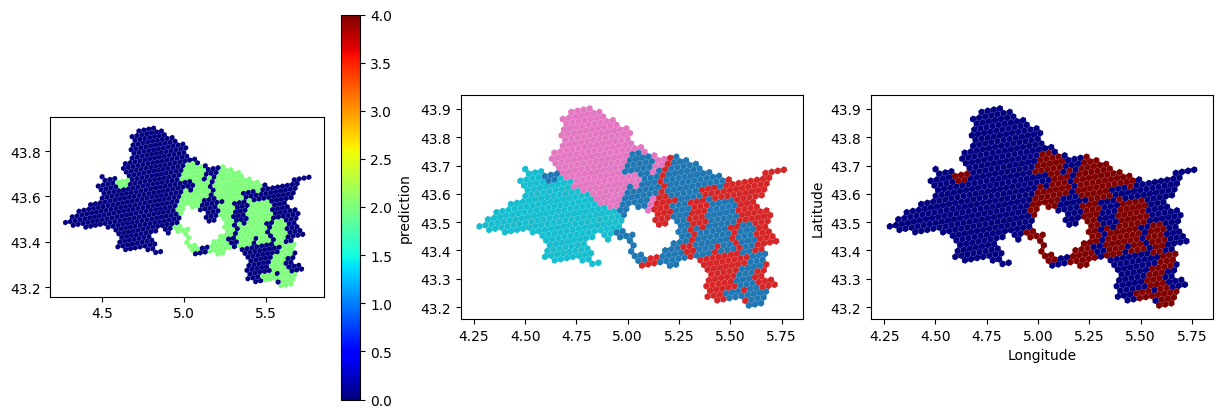

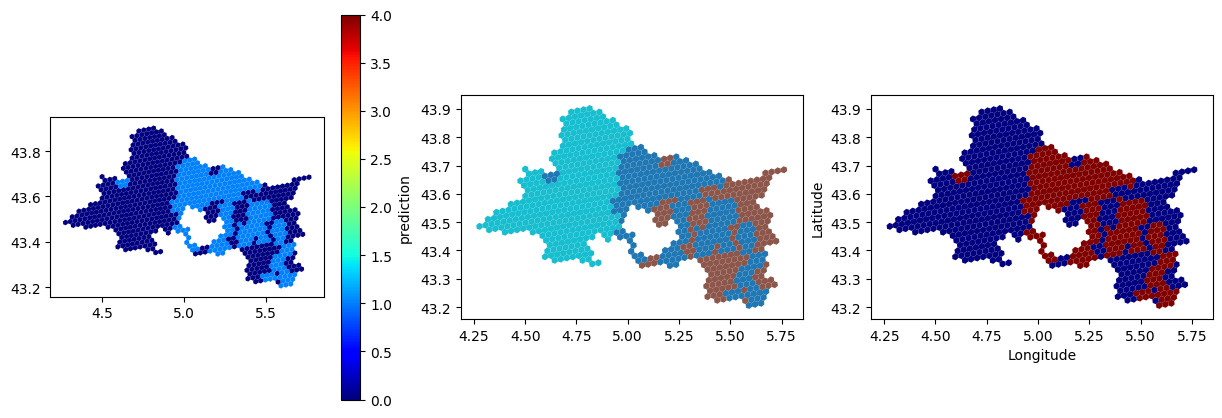

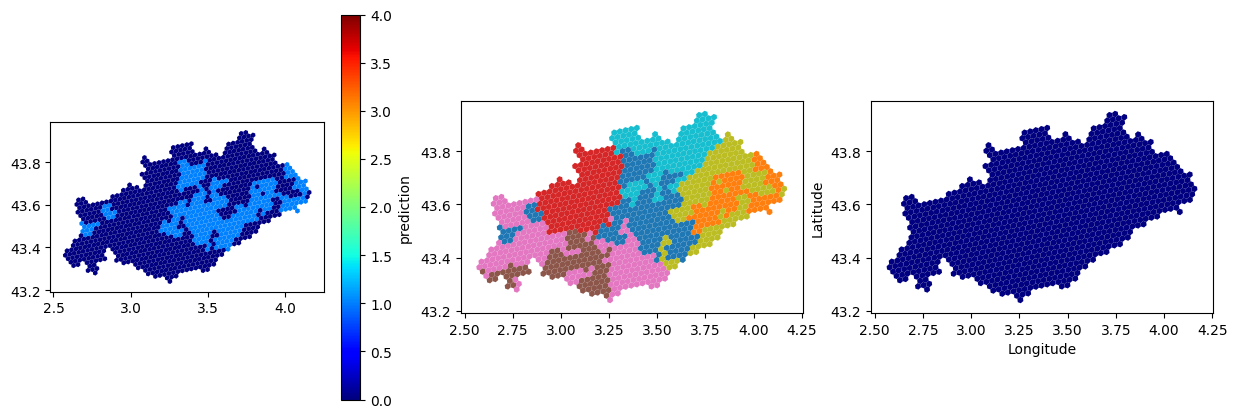

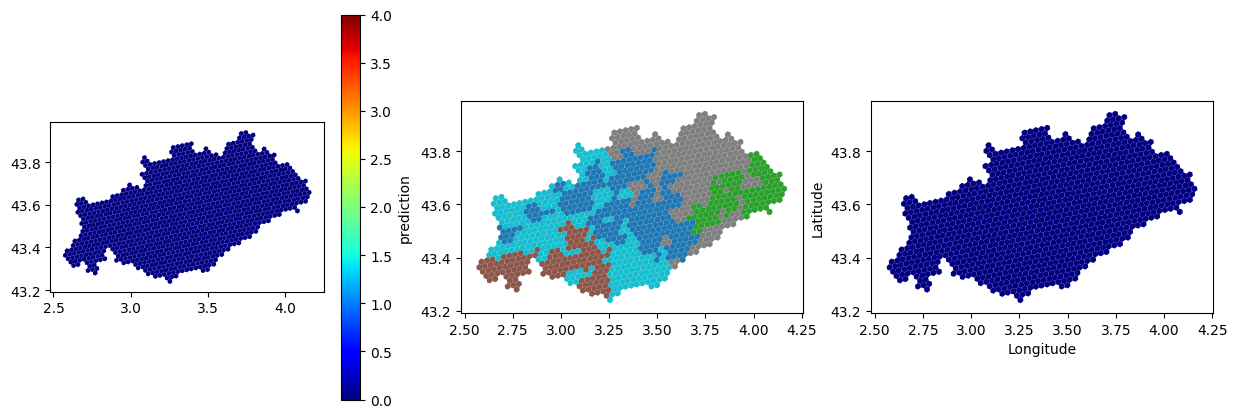

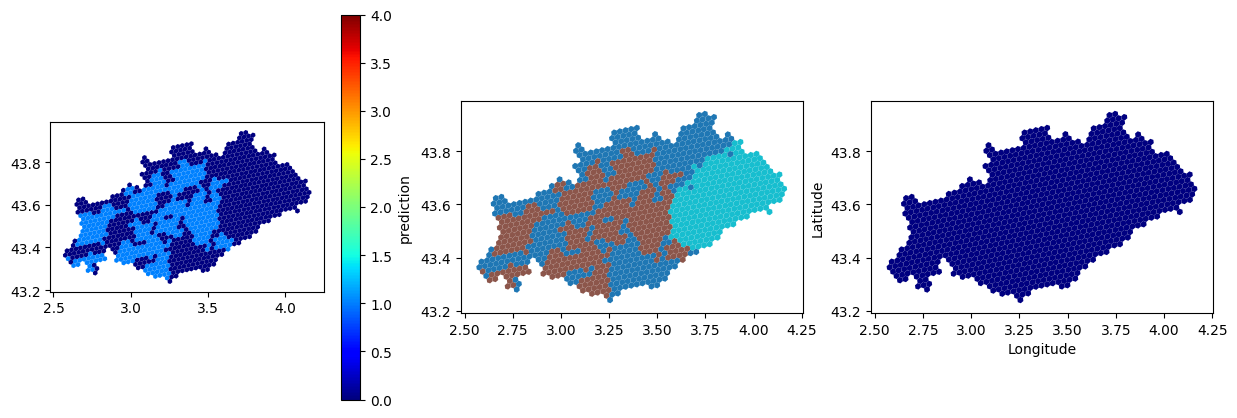

In [45]:
base = 'risk-size-watershed'
model = 'xgboost_search_full_all_one_nbsinister-kmeans-5-Class-Dept_classification_softmax'
path_to_dfs = Path('bdiff_small/firepoint/2x2/test/occurence_voting/')

departement = 'departement-13-bouches-du-rhone'

scales = ['5', '6', '7']

for scale in scales:
    dates = ['2023-08-30']
    dates = [allDates.index(d) for d in dates]
    res = load_res_departement(path_to_dfs, departement, base, model, scale)

    graph_path = Path('bdiff_small') / 'firepoint' / '2x2' / 'train'
    graph = read_object(f'graph_{scale}_{base}_node.pkl', graph_path)

    susectibility_map_france_daily_geojson(res, regions_france, graph, dates, 'prediction', 4, departement)

departement = 'departement-34-herault'

scales = ['5', '6', '7']

for scale in scales:
    dates = ['2023-08-31']
    dates = [allDates.index(d) for d in dates]
    res = load_res_departement(path_to_dfs, departement, base, model, scale)

    graph_path = Path('bdiff_small') / 'firepoint' / '2x2' / 'train'
    graph = read_object(f'graph_{scale}_{base}_node.pkl', graph_path)

    susectibility_map_france_daily_geojson(res, regions_france, graph, dates, 'prediction', 4, departement)
